## **1. Projeto de Inteligência Artificial 2025/2026: Agentes para o Jogo PopOut**

**Faculdade de Ciências da Universidade do Porto (FCUP)** **Unidade Curricular:** Inteligência Artificial (CC2006)  
**Turma:** CC2006_PL1 | **Grupo:** 3  
**Docente:** Prof. Francesco Renna  

### **Equipe de Desenvolvimento**
| Número | Nome |
| :--- | :--- |
| **202300654** | Augusto Moreira |
| **202300276** | Guilherme Klippel |
| **202300916** | Yan Coelho |

---

### **Introdução e Contexto do Problema**

Este notebook documenta a conceção, implementação e análise de agentes de Inteligência Artificial para o jogo **PopOut**, uma variante estratégica e dinâmica do clássico *Connect-4* (Quatro em Linha). Tratando-se de um jogo de tabuleiro de soma nula e informação perfeita, o PopOut apresenta um desafio acrescido devido à sua mecânica de remoção de peças, que aumenta significativamente a complexidade e o fator de ramificação (*branching factor*) da árvore de jogo.

O objetivo deste projeto divide-se em duas abordagens fundamentais da IA:
1. **Procura Adversarial:** Implementação de um agente baseado em **Monte Carlo Tree Search (MCTS)** para atuar como um jogador de elite (*expert*).
2. **Aprendizagem Automática:** Utilização do MCTS para gerar conjuntos de dados de alta qualidade, servindo de base para o treino de um modelo de **Árvores de Decisão (algoritmo ID3)**, capaz de inferir regras táticas a partir das jogadas guardadas nos datasets.

### **Mecânicas e Regras Especiais**

A nossa implementação na classe base `PopOutGame` suporta o tabuleiro normal de 6x7 e introduz as seguintes ações:
* **Drop:** Colocação de uma peça no topo de uma coluna, caindo até à posição livre mais baixa.
* **PopOut:** Remoção de uma peça do próprio jogador na base (linha inferior) de uma coluna, fazendo com que todas as peças acima desçam uma posição.

Para garantir a robustez das simulações, foram rigorosamente implementadas as **três regras especiais** exigidas no guião:
* **Regra 1 (Vitória Simultânea):** Se uma jogada *PopOut* alinhar simultaneamente 4 peças para ambos os jogadores, a vitória é atribuída ao jogador que efetuou o movimento.
* **Regra 2 (Tabuleiro Cheio):** Caso a linha superior do tabuleiro esteja totalmente preenchida, o movimento *Drop* torna-se inválido, forçando o jogador a executar um *PopOut* (ou declarar derrota caso não tenha peças na base).
* **Regra 3 (Empate por Repetição):** O sistema monitoriza o histórico de estados (através de *hashes* do tabuleiro). Se o mesmo estado se repetir 3 vezes durante a partida, o jogo é declarado como empate.

---

#### Importes

In [1]:
%load_ext autoreload
%autoreload 2
from src.game import PopOutGame, _get_ai_move, PLAYER1, PLAYER2
import os
import warnings
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import numpy as np
# Módulos locais
from src.decision_tree import (
    DecisionTreeID3,
    clean_conflicting_data,
    discretizar_largura_igual,
    discretizar_frequencia_igual,
    calcular_metricas,
    plotar_arvore_decisao
)
from src.game import PopOutGame, main_menu
from src.mcts import MCTS
from src.dataset_generator import run_batch_simulation

# Configurações globais
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
os.makedirs("datasets", exist_ok=True)

## **2. Fase de Testes**
Aqui testamos a mecânica base do jogo integrando dois módulos principais:

* **`ui.py`**: Interface e renderização visual do tabuleiro no terminal.
* **`game.py`**: Motor do jogo (`PopOutGame`), responsável por validar regras, jogadas e vitórias.


In [ ]:
def carregar_arvore(nome_arvore):
    """Função auxiliar para carregar uma árvore do disco para a memória."""
    caminho = f"modelos_treinados/{nome_arvore}.pkl"
    try:
        with open(caminho, 'rb') as f:
            # Forçar o print a aparecer IMEDIATAMENTE com flush=True
            print(f"[OK] Árvore carregada: {nome_arvore}", flush=True)
            return pickle.load(f)
    except FileNotFoundError:
        print(f"[ERRO] Ficheiro não encontrado: {caminho}. Corra o gerador primeiro!", flush=True)
        return None

# ==============================================================
# 1. CARREGAR AS ÁRVORES PREVIAMENTE TREINADAS
# ==============================================================
print("A carregar cérebros da IA do disco...", flush=True)
tree1_pronta = carregar_arvore("arvore_elite_win_only")
tree2_pronta = carregar_arvore("arvore_geral_completa")

# ==============================================================
# 2. CONFIGURAR OS MONTE CARLOS
# ==============================================================
montecarlos1 = MCTS(iterations=100, c=1.41, max_children=None, max_depth= 5)
montecarlos2 = MCTS(iterations=100, c=1.41, max_children=None, max_depth= None)

# ==============================================================
# 3. INICIAR O MENU GESTOR
# ==============================================================
if tree1_pronta is not None and tree2_pronta is not None:
    print("\nTodas as IAs prontas! A iniciar o sistema em 2 segundos...", flush=True)
    
    # Pausa de 2 segundos para conseguir ler os OKs antes do ecrã limpar
    time.sleep(2) 
    
    main_menu(mcts1=montecarlos1, mcts2=montecarlos2, tree1=tree1_pronta, tree2=tree2_pronta)
else:
    print("\n[!] O sistema não pode iniciar porque faltam modelos de IA.", flush=True)

## **3. Geração de Datasets (MCTS)**
Nesta etapa, utilizamos simulações de **Monte Carlo Tree Search (MCTS)** (IA vs IA) para gerar um histórico de jogadas de alta qualidade. Estes dados servirão de base para o treino posterior do classificador ID3.

* **Simulação Automática (`run_batch_simulation`)**: Coordena as partidas garantindo a aplicação estrita das regras (PopOut, Vitória Dupla, Empate por Repetição).
* **Rastreabilidade**: O nome dos ficheiros CSV é gerado dinamicamente com base nos hiperparâmetros usados: `it` (Iterações), `c` (Constante de Exploração) e `mc` (Max Children).
* **Estrutura dos Dados**: Cada registo no dataset captura um estado do jogo, contendo as 42 posições do tabuleiro (*features*) e a jogada ótima decidida (*target*).

In [ ]:
# Configuração das instâncias MCTS para treino
ia_elite = MCTS(iterations=1000, c=1.41, max_children=None, max_depth= None)
ia_caos = MCTS(iterations=1000, c=3, max_children=None, max_depth= None)
ia_limitada = MCTS(iterations=1000, c=1.41, max_children=3, max_depth= None)
ia_profunda = MCTS(iterations=1000, c=1.41, max_children=None, max_depth= 30)


# Execução dos lotes de simulação
run_batch_simulation(num_games=56, ia_1=ia_limitada, ia_2=ia_limitada)
run_batch_simulation(num_games=100, ia_1=ia_profunda, ia_2=ia_profunda)

print("Processo concluído. Ficheiros guardados na pasta 'datasets/'.")


[SISTEMA] A gerar lote de 56 jogos...
[ARQUIVO] datasets/P1_it1000_c1.41_mc3_dNone_vs_P2_it1000_c1.41_mc3_dNone.csv


## **4. Treino e Geração da Árvore de Decisão**
Nesta etapa, utilizamos o algoritmo **ID3** para transformar os dados brutos gerados pelo MCTS num classificador de decisões lógicas. 

O grande destaque desta fase é a implementação da **Normalização de Perspetiva Relativa**. Em vez de a Árvore aprender táticas separadas para o "Jogador 1" e "Jogador 2", o dataset é convertido para uma matriz universal de "Eu (1)" vs "Inimigo (-1)". Esta abordagem:
* Reduz drasticamente o espaço de estados que a árvore precisa de memorizar.
* Maximiza a eficácia do cálculo de Entropia e Ganho de Informação.
* Permite ao modelo generalizar táticas avançadas independentemente de quem tem a iniciativa de jogo.

In [ ]:
def gerar_e_guardar_arvore(caminho_dataset, nome_arvore, only_winners=True, max_depth=10):
    """
    Carrega o dataset, aplica filtros de qualidade, normaliza a perspetiva do tabuleiro, 
    treina o modelo ID3 e serializa-o em formato .pkl para inferência futura.
    """
    print(f"\n--- A INICIAR GERAÇÃO: {nome_arvore} ---")
    df = pd.read_csv(caminho_dataset)
    
    # 1. Filtro de Qualidade: Otimizar o modelo mantendo apenas decisões de vitórias efetivas
    if only_winners:
        df = df[(df['winner'] != 0) & (df['p_turn'] == df['winner'])]
        
    # 2. Normalização de Perspetiva Relativa (Eu=1, Inimigo=-1, Vazio=0)
    print("A normalizar a perspetiva tática do tabuleiro...")
    colunas_tabuleiro = [f"pos_{i}" for i in range(42)]
    
    for col in colunas_tabuleiro:
        # Converte a peça bruta para uma métrica tática universal ("Minha Peça" ou "Peça Adversária")
        df[col] = np.where(df[col] == 0, 0, 
                  np.where(df[col] == df['p_turn'], 1, -1))
        
    # 3. Preparação das Features e Target
    df["target_move"] = df["col"].astype(str) + "_" + df["type"]
    
    # Removemos o ID do turno (pois a perspetiva já foi abstraída) e metadados irrelevantes
    df_clean = df.drop(columns=["game_id", "winner", "col", "type", "p_turn"])
    
    # 4. Limpeza de Ruído: Resolução de ambiguidades do MCTS (agrupamento pela moda)
    df_clean = clean_conflicting_data(df_clean, target_name="target_move")
    
    # 5. Instanciação e Treino do Modelo
    tree = DecisionTreeID3(max_depth=max_depth)
    print("A treinar a estrutura de decisão ID3...")
    tree.fit(df_clean, target_name="target_move")
    
    # 6. Serialização do Modelo
    os.makedirs("modelos_treinados", exist_ok=True)
    caminho_ficheiro = f"modelos_treinados/{nome_arvore}.pkl"
    
    with open(caminho_ficheiro, 'wb') as f:
        pickle.dump(tree, f)
        
    print(f"[SUCESSO] Modelo guardado com sucesso: {caminho_ficheiro}")


# =====================================================================
# CONFIGURAÇÃO DE TREINO E EXPORTAÇÃO
# =====================================================================
dataset = "datasets\P1_it1000_c1_mc7_vs_P2_it1000_c1_mc7.csv"

# Treina o classificador principal focado em estratégias vencedoras
gerar_e_guardar_arvore(
    caminho_dataset=dataset, 
    nome_arvore="arvore_geral_completa", 
    only_winners=True, 
    max_depth=100
)

## **5. Fase de Análise Exploratória de Dados**

Esta fase é dedicada à auditoria visual do dataset gerado pelo **MCTS**. Antes de alimentar a Árvore de Decisão (**ID3**), precisamos de garantir que a informação estratégica capturada faz sentido. Com a introdução do rastreamento de vitórias (`winner` e `game_id`), a nossa análise deixa de observar apenas o volume geral e foca-se puramente na extração de táticas bem-sucedidas.

### Objetivos da Visualização
* **Qualidade dos Dados:** Garantir que o modelo ID3 irá aprender com instâncias de excelência estratégica, **removendo jogos empatados do processo de análise**.
* **Validação Tática:** Confirmar o peso estatístico do domínio da zona central do tabuleiro e o uso estratégico da mecânica de *PopOut*.
* **Contraste de Eficiência:** Isolar o comportamento das "Jogadas Vencedoras" contra as "Jogadas Perdedoras" para perceber o que separa uma IA comum de uma IA de elite.

---

### Dashboard de Performance e Estratégia
O script compila um painel com 8 painéis críticos focados no comportamento em partidas decisivas:

1. **Resultados Finais das Partidas**: Exibe a taxa de vitórias diretas (P1 vs P2), comprovando qual a configuração MCTS que obteve maior dominância.
2. **Volume Total de Jogadas**: Revela a quantidade de ações executadas no tabuleiro por cada lado.
3. **Distribuição de Colunas**: Identifica o volume global de jogadas em cada coluna.
4. **Proporção Global (Drop vs Pop)**: Analisa o rácio global de utilização da regra especial em relação à mecânica clássica.
5. **Foco Estratégico (Vencedores vs Perdedores)**: O indicador de maior valor para o algoritmo ID3. Isola e compara as colunas jogadas especificamente por quem, no fim, garantiu a vitória.
6. **Uso de Regras (Vencedores vs Perdedores)**: Demonstra se os vencedores recorrem mais vezes, ou de forma mais cirúrgica, à mecânica *PopOut* comparativamente aos derrotados.
7. **Mapa de Ocupação (Heatmap)**: Um mapa térmico da grelha (6x7) para mapear a concentração e disputa do território.
8. **Zonas de PopOut**: Detalha especificamente onde ocorrem as jogadas de remoção de peça, diferenciando o sucesso da ação.

In [ ]:
caminho_ficheiro = "datasets/P1_it10000_c1.41_mcAll_dNone_vs_P2_it10000_c1.41_mcAll_dNone.csv"
nome_do_ficheiro = os.path.basename(caminho_ficheiro)
df = pd.read_csv(caminho_ficheiro)


df = df[df['winner'] != 0].copy()

# Classificação das jogadas (Vencedor ou Perdedor)
df['is_winner'] = (df['p_turn'] == df['winner'])
df['status'] = df.apply(lambda r: 'Vencedor' if r['is_winner'] else 'Perdedor', axis=1)

# Filtra apenas os jogos únicos
df_jogos = df.drop_duplicates(subset=['game_id'])[['game_id', 'winner']]

# CONTAGEM DO TOTAL DE PARTIDAS (Agora só conta jogos decisivos)
total_partidas = len(df_jogos)

fig, axes = plt.subplots(4, 2, figsize=(18, 24))

# TÍTULO ATUALIZADO 
fig.suptitle(f"Análise Global e Estratégica: {nome_do_ficheiro}\nTotal de Partidas Decisivas (Sem Empates): {total_partidas}", fontsize=20, fontweight='bold', y=0.98)

# 1. Resultados Finais dos Jogos (Atualizado sem empate)
sns.countplot(data=df_jogos, x='winner', hue='winner', order=[1, 2], ax=axes[0, 0], palette=['#3498db', '#e74c3c'], legend=False)
axes[0, 0].set_title("1. Resultados Finais das Partidas")
axes[0, 0].set_xticklabels(['Vitória P1 (X)', 'Vitória P2 (O)'])

# 2. Total de Movimentos (Geral)
sns.countplot(data=df, x='p_turn', hue='p_turn', ax=axes[0, 1], palette=['#3498db', '#e74c3c'], legend=False)
axes[0, 1].set_title("2. Volume Total de Jogadas (P1 vs P2)")

# 3. Escolha de Colunas (Geral)
sns.countplot(data=df, x='col', hue='p_turn', ax=axes[1, 0], palette=['#3498db', '#e74c3c'])
axes[1, 0].set_title("3. Distribuição de Colunas: P1 vs P2")

# 4. Rácio Drop vs Pop (Geral)
tipos = df['type'].value_counts()
axes[1, 1].pie(tipos, labels=tipos.index, autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1, 1].set_title("4. Proporção Global: Drop (d) vs Pop (p)")

# 5. Escolha de Colunas (Vencedor vs Perdedor)
sns.countplot(data=df, x='col', hue='status', ax=axes[2, 0], palette=['#2ecc71', '#e67e22'])
axes[2, 0].set_title("5. Foco Estratégico: Vencedores vs Perdedores")

# 6. Uso da Mecânica (Vencedor vs Perdedor)
sns.countplot(data=df, x='type', hue='status', ax=axes[2, 1], palette=['#2ecc71', '#e67e22'])
axes[2, 1].set_title("6. Uso de Regras: Vencedores vs Perdedores")

# 7. Heatmap de Ocupação (Geral)
colunas_tab = [f"pos_{i}" for i in range(42)]
ocupacao = (df[colunas_tab] > 0).mean().values.reshape(6, 7)
sns.heatmap(ocupacao, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[3, 0], cbar=False)
axes[3, 0].set_title("7. Mapa de Ocupação (Zonas Quentes)")

# 8. Onde ocorrem PopOuts? (Vencedor vs Perdedor)
pops = df[df['type'] == 'p']
if not pops.empty:
    sns.countplot(data=pops, x='col', hue='status', ax=axes[3, 1], palette=['#2ecc71', '#e67e22'])
    axes[3, 1].set_title("8. Zonas de PopOut: Vencedores vs Perdedores")
else:
    axes[3, 1].text(0.5, 0.5, "Sem jogadas PopOut", ha='center', va='center')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## **6. Teste no Iris com Discretização**
- **Teste A: Sem Discretização (Dados Originais):** Usa os números decimais puros, demonstrando visualmente como o algoritmo ID3 sofre de *overfitting* sem a devida preparação.
- **Teste B: Discretização por Largura Igual:** Divide a régua de valores em 2 faixas de tamanho exatos.
- **Teste C: Discretização por Frequência (Quantis):** Equilibra os dados para que cada grupo tenha a mesma quantidade de amostras.

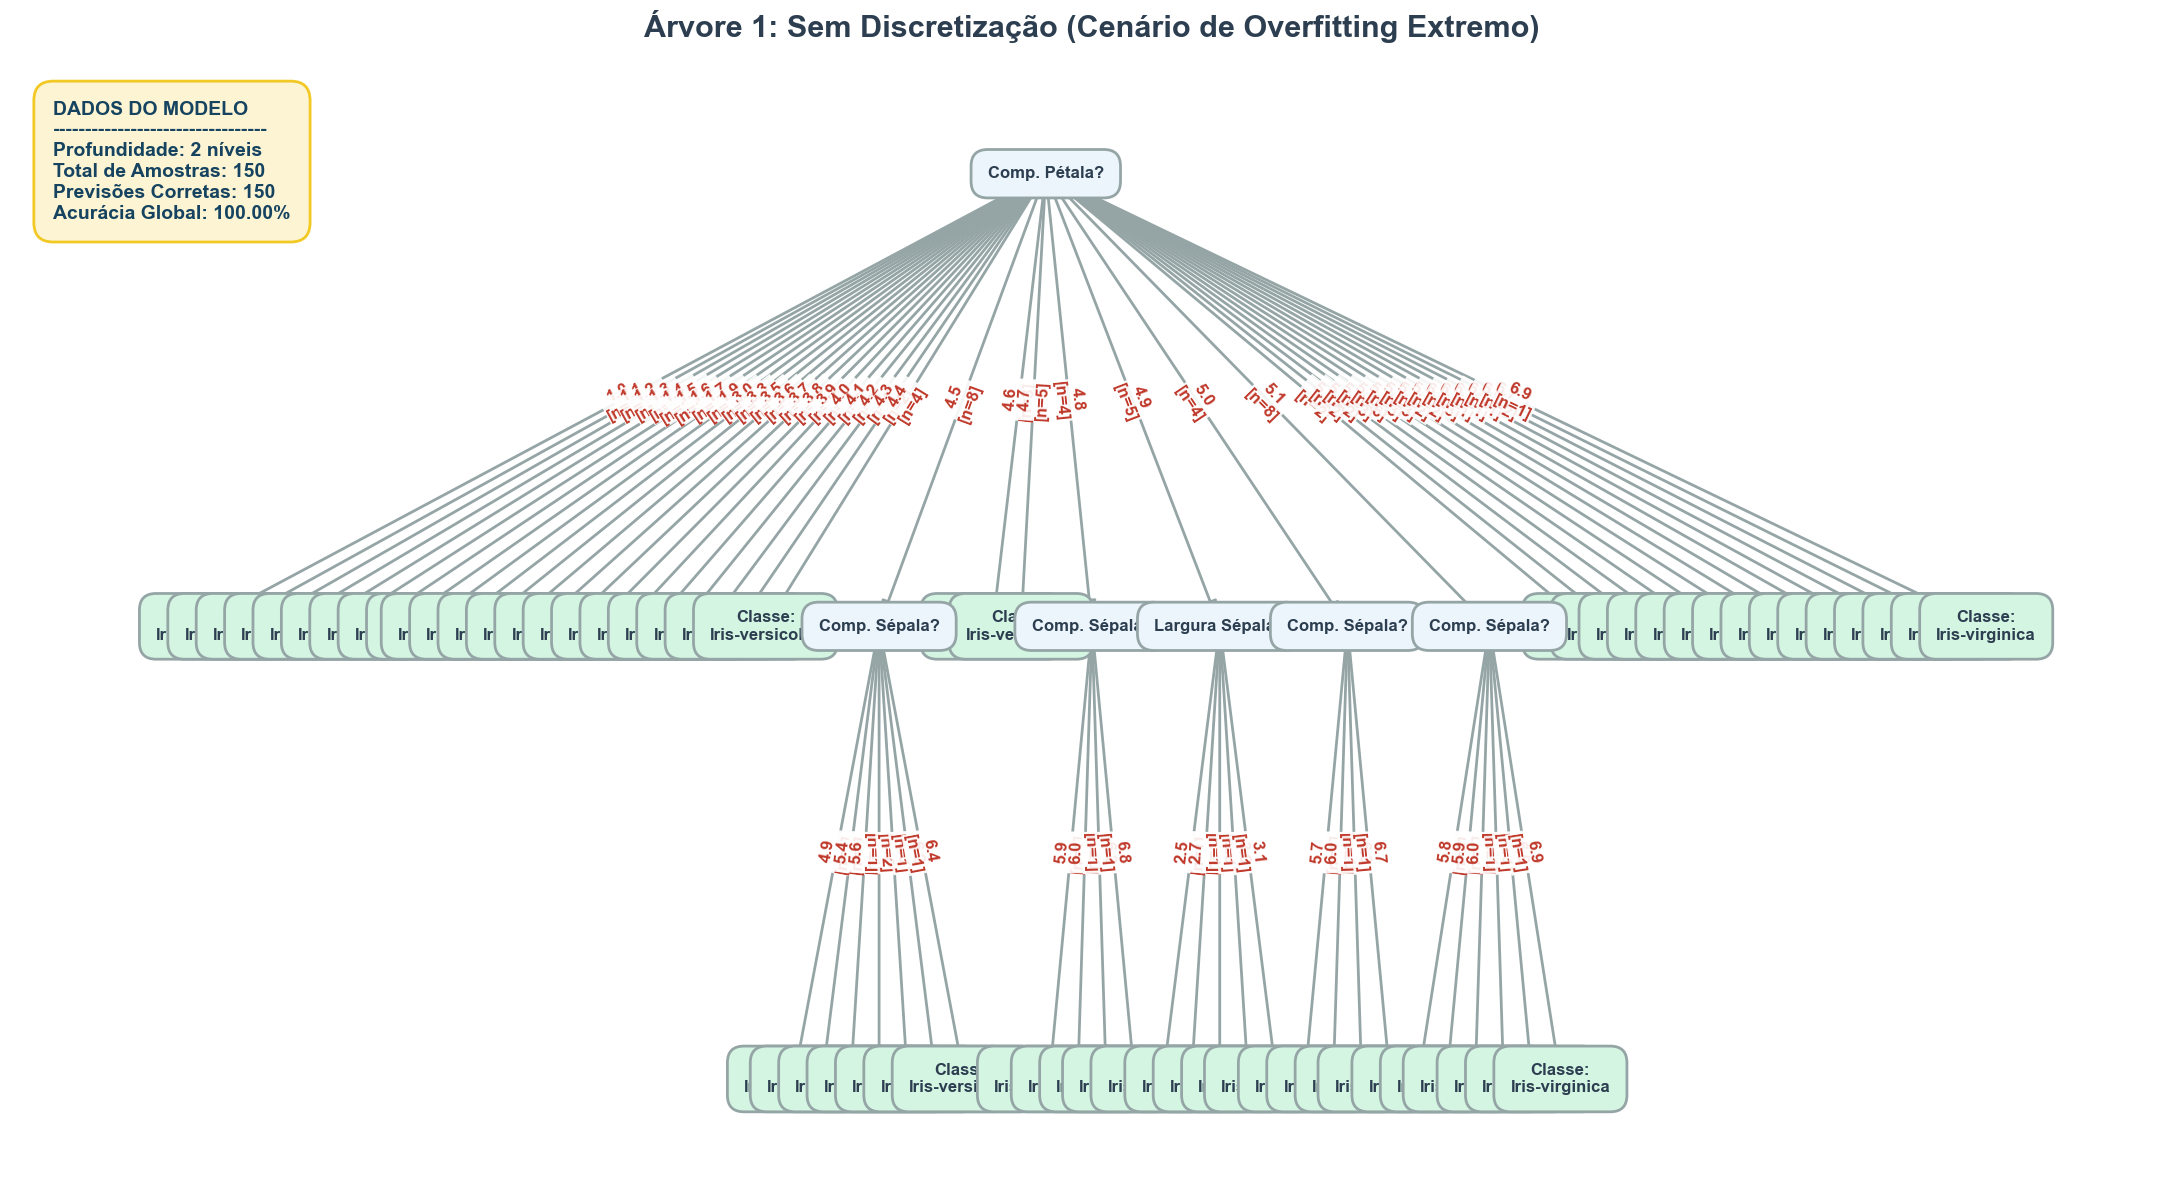

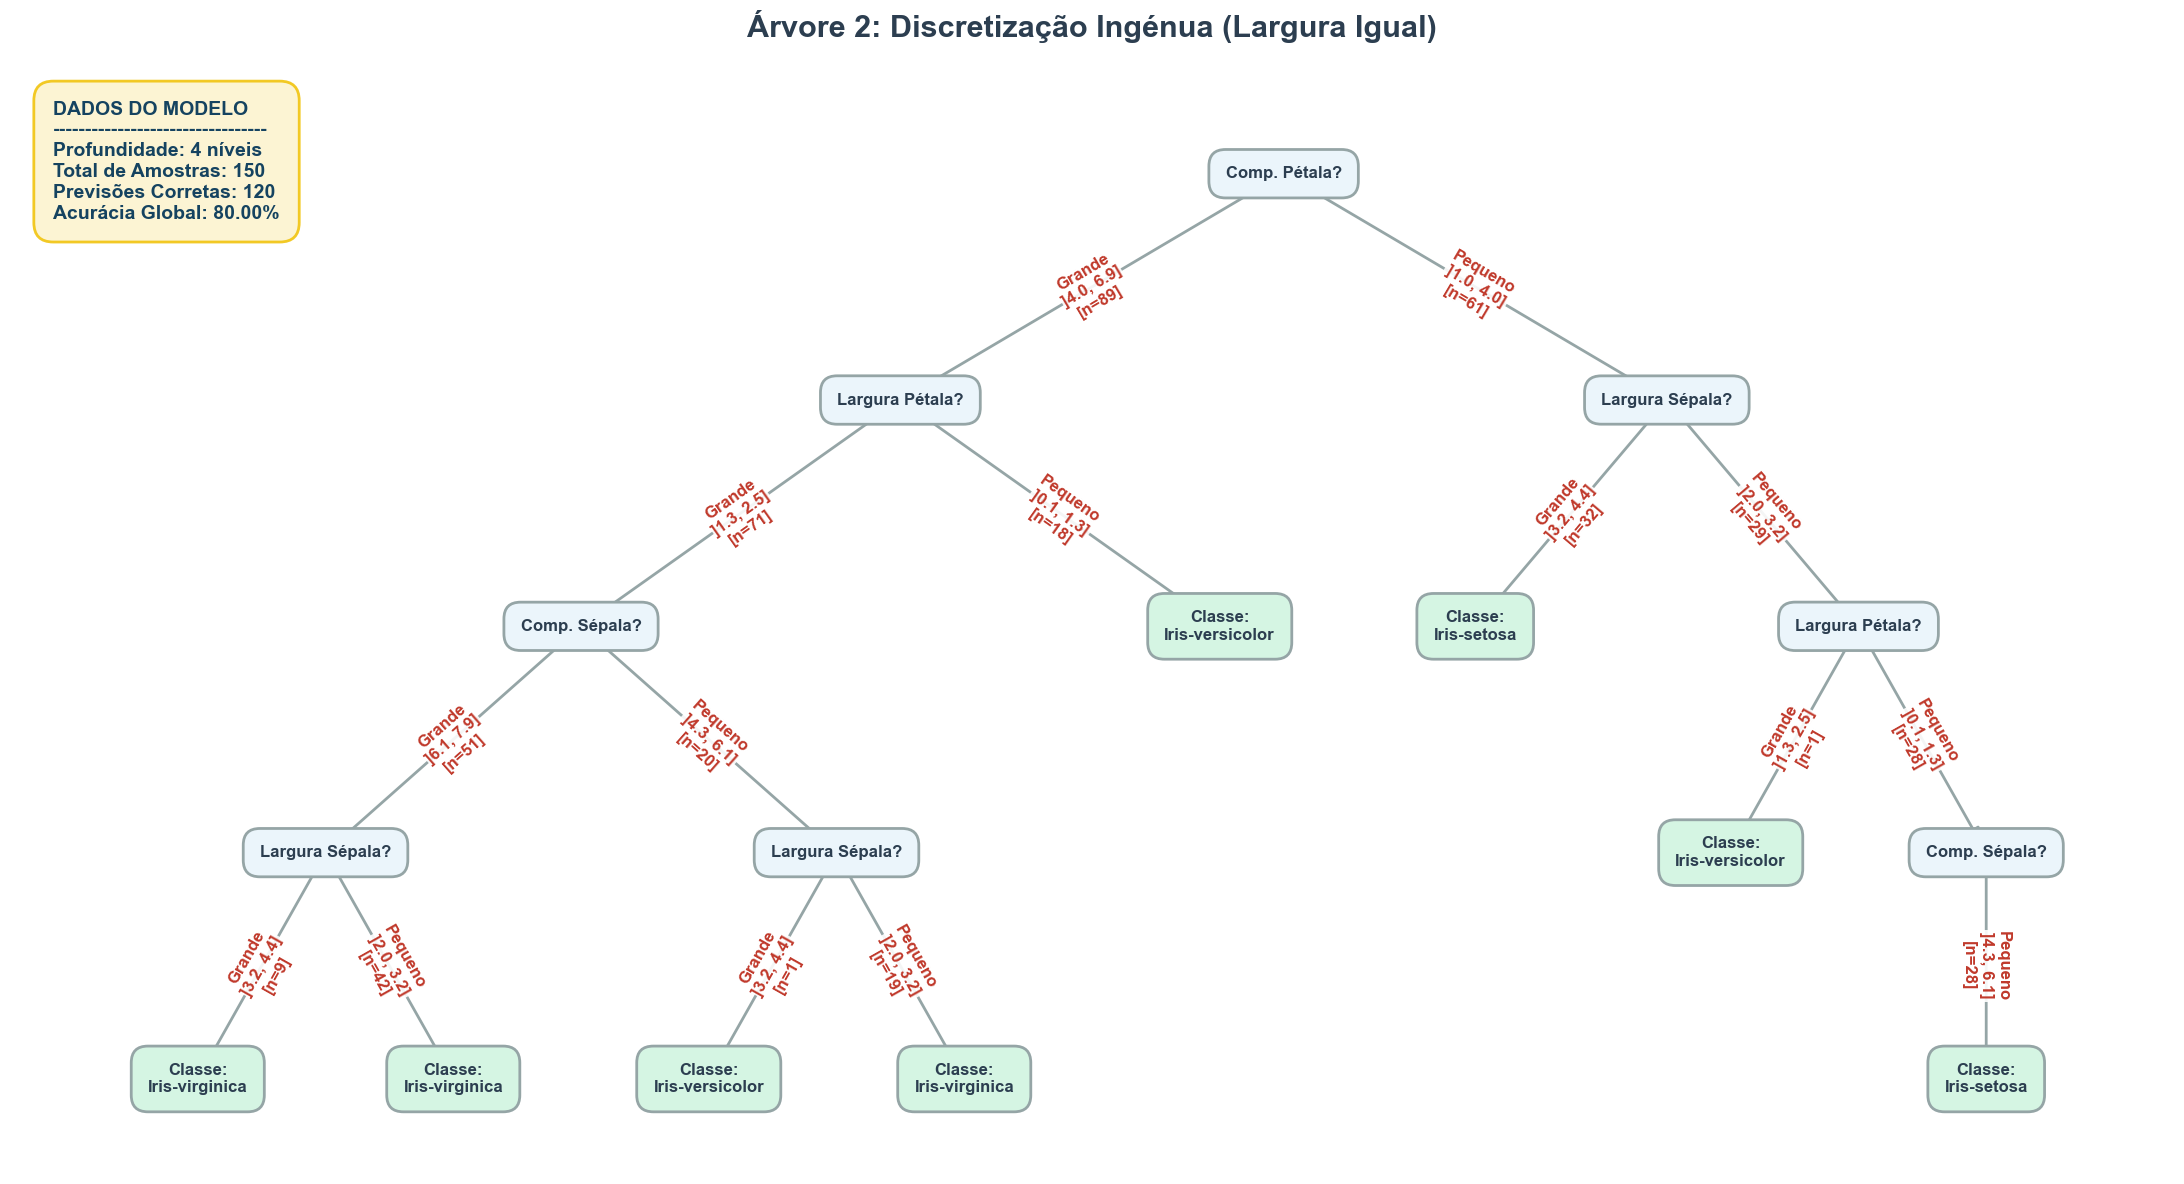

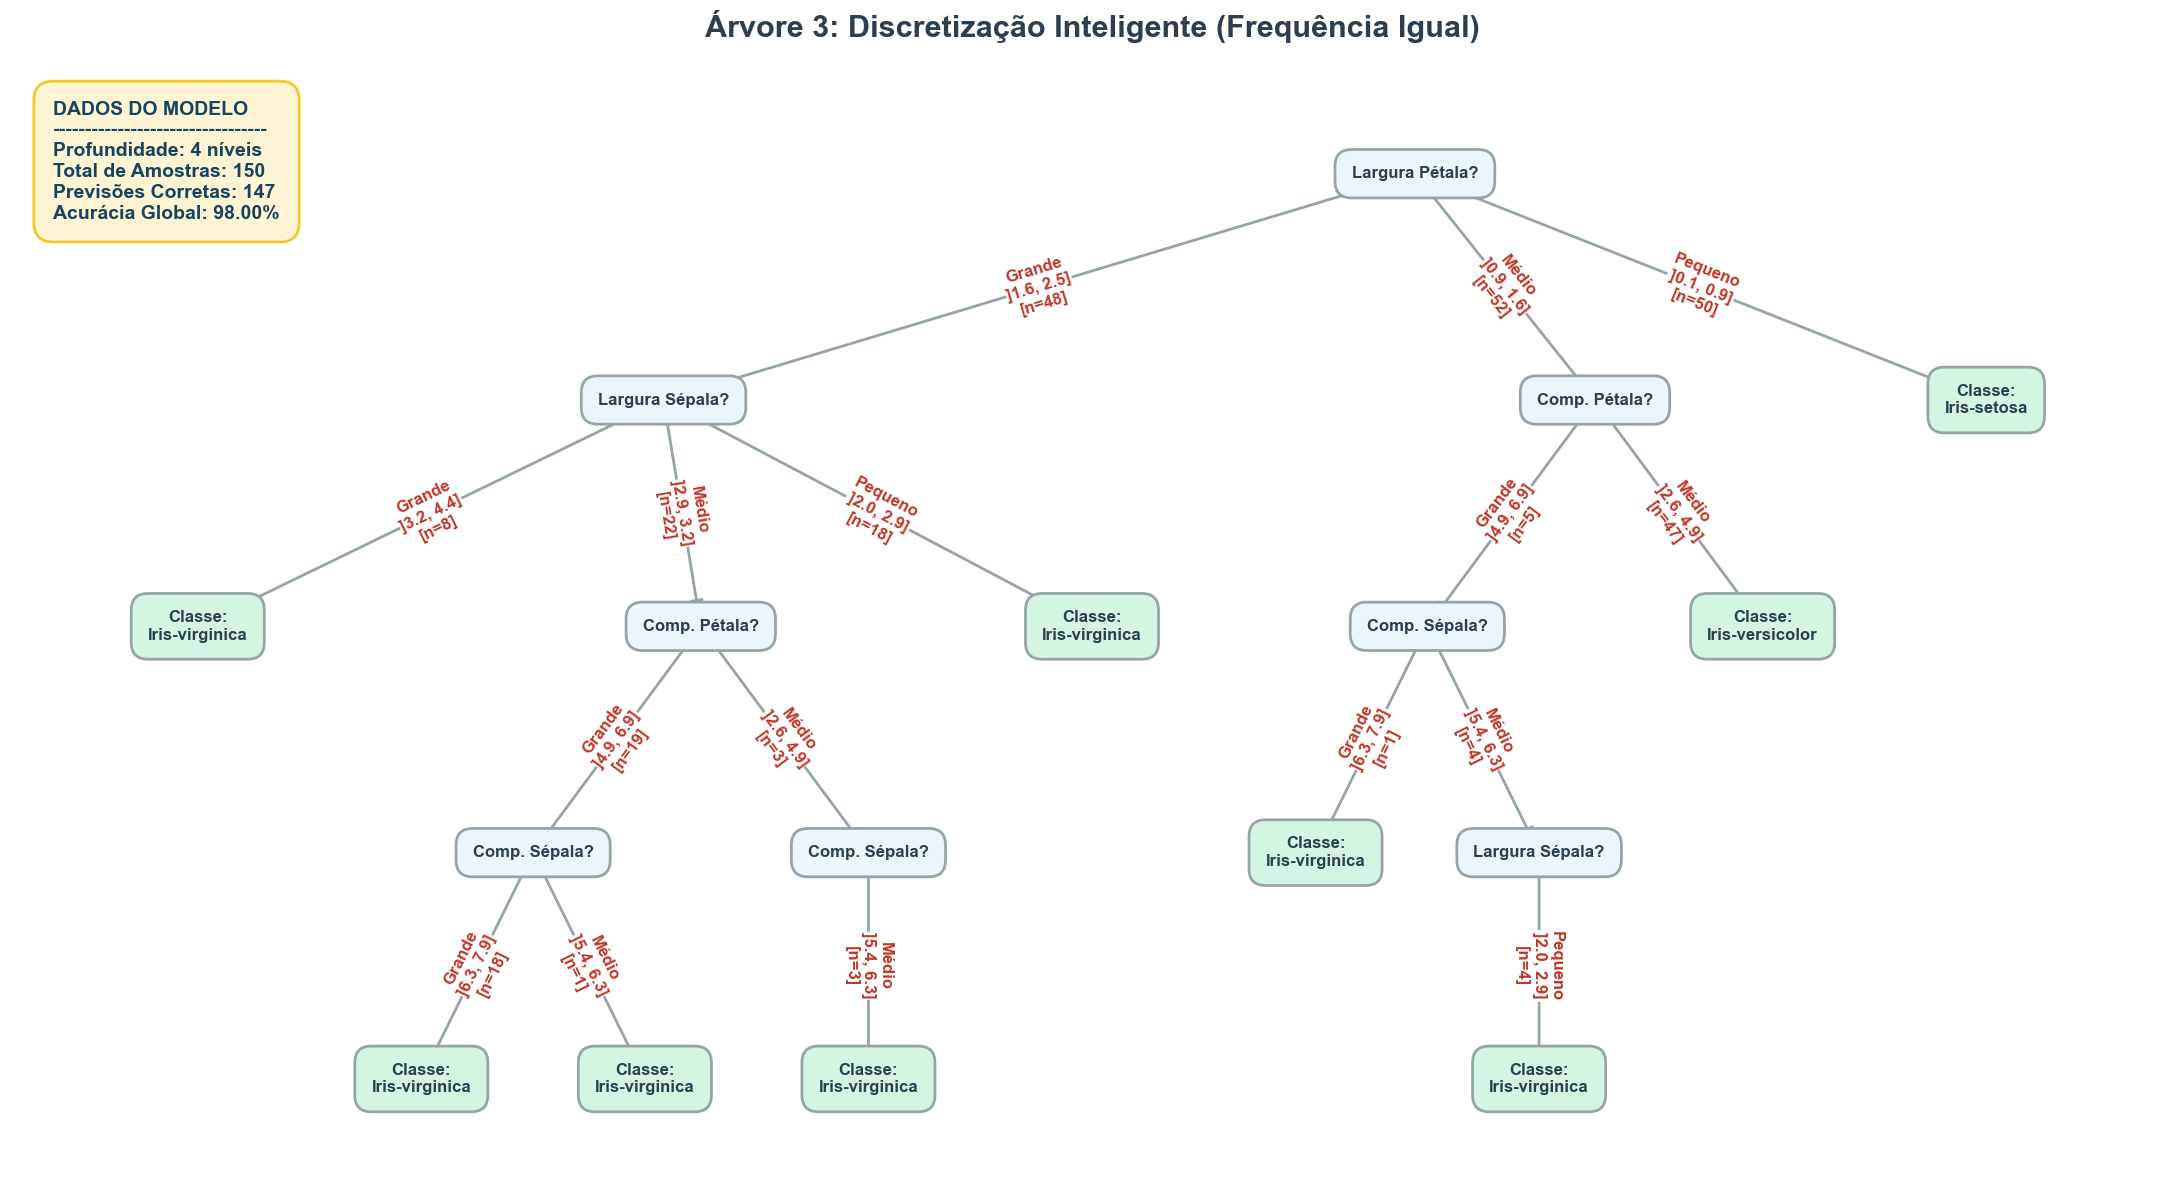

In [7]:
def calcular_profundidade(node):
    if not node.children:
        return 0
    return 1 + max([calcular_profundidade(filho) for filho in node.children.values()])

# 1. Carregar os dados iniciais
caminho_iris = "datasets/iris.csv" 
df_iris = pd.read_csv(caminho_iris)

# --- Traduzir colunas para Português ---
dicionario_traducao = {
    'sepallength': 'Comp. Sépala',
    'sepalwidth': 'Largura Sépala',
    'petallength': 'Comp. Pétala',
    'petalwidth': 'Largura Pétala',
    'class': 'Classe'
}
df_iris = df_iris.rename(columns=dicionario_traducao)

# Atualizar as variáveis com os novos nomes em português
colunas_features = ['Comp. Sépala', 'Largura Sépala', 'Comp. Pétala', 'Largura Pétala']
nome_da_coluna_alvo = 'Classe'
df_iris = df_iris[colunas_features + [nome_da_coluna_alvo]]


# ----------------- TESTE 1: CAOS (Dados Contínuos) -----------------
arvore_continua = DecisionTreeID3(max_depth=5)
arvore_continua.fit(df_iris, target_name=nome_da_coluna_alvo)
metricas_teste_1 = calcular_metricas(arvore_continua, df_iris, nome_da_coluna_alvo)

# --> Calcula e adiciona a profundidade!
metricas_teste_1['profundidade'] = calcular_profundidade(arvore_continua.root) 

plotar_arvore_decisao(arvore_continua.root, 
                      titulo="Árvore 1: Sem Discretização (Cenário de Overfitting Extremo)", 
                      metricas=metricas_teste_1)

# ----------------- TESTE 2: LARGURA IGUAL -----------------
df_ingenua = discretizar_largura_igual(df_iris, colunas_features)
arvore_ingenua = DecisionTreeID3(max_depth=5)
arvore_ingenua.fit(df_ingenua, target_name=nome_da_coluna_alvo)
metricas_teste_2 = calcular_metricas(arvore_ingenua, df_ingenua, nome_da_coluna_alvo)

# --> Calcula e adiciona a profundidade!
metricas_teste_2['profundidade'] = calcular_profundidade(arvore_ingenua.root)

plotar_arvore_decisao(arvore_ingenua.root, 
                      titulo="Árvore 2: Discretização Ingénua (Largura Igual)", 
                      metricas=metricas_teste_2)

# ----------------- TESTE 3: QUANTIS (Frequência Igual) -----------------
df_inteligente = discretizar_frequencia_igual(df_iris, colunas_features)
arvore_inteligente = DecisionTreeID3(max_depth=5)
arvore_inteligente.fit(df_inteligente, target_name=nome_da_coluna_alvo)
metricas_teste_3 = calcular_metricas(arvore_inteligente, df_inteligente, nome_da_coluna_alvo)

# --> Calcula e adiciona a profundidade!
metricas_teste_3['profundidade'] = calcular_profundidade(arvore_inteligente.root)

plotar_arvore_decisao(arvore_inteligente.root, 
                      titulo="Árvore 3: Discretização Inteligente (Frequência Igual)", 
                      metricas=metricas_teste_3)

### **Conclusão**
A nossa experiência demonstra claramente a importância da preparação dos dados. A Árvore 1 (sem discretização) obteve 100% de acurácia, mas é um caso clássico de overfitting: a árvore memorizou o treino e não conseguiria prever dados novos. A Árvore 2 (Largura Igual) evitou o overfitting, mas a sua divisão cega da "régua" de valores misturou espécies diferentes, afundando a acurácia para 80%.

A Árvore 3 (Frequência Igual / Quantis) foi a abordagem ideal. Ao respeitar a densidade e a distribuição real dos dados, o algoritmo ID3 conseguiu maximizar o Ganho de Informação, gerando um modelo compacto, sem overfitting e com uma excelente acurácia de 98%.

---

#### *Gerador da árvore criada pelo Monte Carlos*

In [ ]:
# 1. Função matemática para calcular a profundidade real do modelo
def calcular_profundidade(node):
    if not node.children:
        return 0
    return 1 + max([calcular_profundidade(filho) for filho in node.children.values()])

# 2. O "Remendo" para evitar o erro do 'branch_counts'
def corrigir_arvore_antiga(node):
    if not hasattr(node, 'branch_counts'):
        node.branch_counts = {}
    for filho in node.children.values():
        corrigir_arvore_antiga(filho)

# 3. A função que carrega, calcula e plota diretamente
def carregar_e_plotar_arvore(nome_arvore):
    caminho = f"modelos_treinados/{nome_arvore}.pkl"
    
    try:
        with open(caminho, 'rb') as f:
            arvore = pickle.load(f)
            
        corrigir_arvore_antiga(arvore.root)
        
        # ---> Calcula a profundidade usando a função nova
        prof_maxima = calcular_profundidade(arvore.root)
        
        # Envia apenas a profundidade para o quadro amarelo!
        minhas_metricas = {
            'profundidade': prof_maxima
        }
        
        print(f"A gerar o gráfico para '{nome_arvore}' com {prof_maxima} níveis... (Pode demorar alguns segundos)")
        plotar_arvore_decisao(arvore.root, 
                              titulo=f"Visão da Árvore: {nome_arvore}", 
                              metricas=minhas_metricas)
        
    except FileNotFoundError:
        print(f"[ERRO] Não encontrei o ficheiro: {caminho}")

# =======================================================
# BASTA ESCREVER AQUI O NOME DA ÁRVORE QUE QUER VER:
# =======================================================

carregar_e_plotar_arvore("arvore_geral_completa")

# Para ver a outra, basta descomentar a linha abaixo:
# carregar_e_plotar_arvore("arvore_elite_win_only")

## **7. Arena de Benchmark: Torneio Automático de IA**

Nesta secção, implementamos um motor de torneio para colocar os diferentes modelos de IA a competir diretamente entre si (por exemplo, a Árvore de Decisão treinada contra o MCTS original). 

O objetivo aqui não é visualizar o tabuleiro turno a turno, mas sim executar dezenas ou centenas de partidas de forma rápida e silenciosa. No final da simulação, os resultados de cada jogo (quem venceu, se houve empate e o número total de jogadas) são automaticamente guardados num *dataset* (ficheiro CSV). Isto permite-nos extrair métricas sólidas para comparar o desempenho, a eficiência e a taxa de vitórias de cada abordagem no nosso relatório final.

In [ ]:
# ==============================================================
# 1. FUNÇÕES AUXILIARES DE CARREGAMENTO
# ==============================================================
def carregar_arvore(nome_arvore):
    caminho = f"modelos_treinados/{nome_arvore}.pkl"
    try:
        with open(caminho, 'rb') as f:
            print(f"[OK] Árvore carregada: {nome_arvore}", flush=True)
            return pickle.load(f)
    except FileNotFoundError:
        print(f"[ERRO] Ficheiro não encontrado: {caminho}.", flush=True)
        return None

# ==============================================================
# 2. MOTOR DO TORNEIO AUTOMÁTICO (COM TROCA DE TURNOS JUSTA)
# ==============================================================
def run_tournament(num_games, ia_1, ia_2, name_ia1="P1", name_ia2="P2"):
    output_file = f"resultados/benchmark_{name_ia1}_vs_{name_ia2}.csv"
    
    print(f"\n[SISTEMA] Iniciando Torneio Justo: {num_games} partidas.")
    print(f"[DUELO] {name_ia1} VS {name_ia2}")
    
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    
    vitorias_p1, vitorias_p2, empates = 0, 0, 0
    start_time = time.time()
    
    for i in range(num_games):
        game = PopOutGame()
        num_moves = 0
        
        # LOGICA DE TROCA JUSTA DE TURNOS
        # Se 'i' for par (0, 2, 4...), a IA_1 original joga com as Vermelhas (PLAYER1) e começa.
        # Se 'i' for impar (1, 3, 5...), a IA_2 original joga com as Vermelhas (PLAYER1) e começa.
        ia_1_comeca = (i % 2 == 0)
        
        if ia_1_comeca:
            agente_player1 = ia_1
            agente_player2 = ia_2
            nome_quem_comeca = name_ia1
        else:
            agente_player1 = ia_2
            agente_player2 = ia_1
            nome_quem_comeca = name_ia2
            
        while True:
            # Proteção contra loops
            if game.check_repetition() or num_moves > 150:
                winner_player = 0 # Empate
                break
                
            curr_ia = agente_player1 if game.current_player == PLAYER1 else agente_player2
            move = _get_ai_move(curr_ia, game)
            
            if move is None:
                winner_player = 0 # Empate
                break
                
            col, m_type = move
            if m_type == 'd':
                game.drop_piece(col, game.current_player)
            else:
                game.pop_piece(col, game.current_player)
                
            num_moves += 1
            
            vencedor_atual = game.check_winner_after_move(game.current_player)
            if vencedor_atual is not None:
                winner_player = vencedor_atual
                break
                
            game.current_player = PLAYER2 if game.current_player == PLAYER1 else PLAYER1
        
        # TRADUZIR O VENCEDOR DO TABULEIRO PARA O NOME DA IA ORIGINAL
        if winner_player == 0:
            empates += 1
            resultado_str = "Empate"
        elif (winner_player == PLAYER1 and ia_1_comeca) or (winner_player == PLAYER2 and not ia_1_comeca):
            # Ganhou a IA_1 original (quer ela tenha jogado como P1 ou P2)
            vitorias_p1 += 1
            resultado_str = name_ia1
        else:
            # Ganhou a IA_2 original
            vitorias_p2 += 1
            resultado_str = name_ia2
            
        # Gravação Imediata
        partida_atual = [{
            "P1": name_ia1,
            "P2": name_ia2,
            "Vencedor": resultado_str,
            "Quem_Comecou": nome_quem_comeca, # Adicionei isto para saberes quem tinha a vantagem!
            "Total_Jogadas": num_moves
        }]
        
        df_partida = pd.DataFrame(partida_atual)
        file_exists = os.path.isfile(output_file)
        df_partida.to_csv(output_file, mode='a', header=not file_exists, index=False)
        
        print(f" > Jogo {i + 1}/{num_games} salvo | Começou: {nome_quem_comeca} | Vencedor: {resultado_str} | Jogadas: {num_moves}")
            
    elapsed_time = time.time() - start_time
    
    print("\n" + "="*40)
    print(f"RESUMO DO LOTE - Tempo: {elapsed_time:.2f}s")
    print("="*40)
    print(f"Vitórias {name_ia1}: {vitorias_p1}")
    print(f"Vitórias {name_ia2}: {vitorias_p2}")
    print(f"Empates: {empates}")
    print(f"-> Ficheiro atualizado com sucesso em: {output_file}")
    
    return pd.read_csv(output_file)

# ==============================================================
# 3. SETUP E EXECUÇÃO
# ==============================================================
print("A carregar cérebros da IA do disco...", flush=True)
tree_elite = carregar_arvore("arvore_elite_win_only")
tree_geral = carregar_arvore("arvore_geral_completa")

mcts_rapido = MCTS(iterations=500, c=1.41, max_children= None, max_depth= None)
mcts_profundo = MCTS(iterations=100, c=1.41, max_children= None, max_depth= None)

if tree_elite is not None:

    agente_teste = mcts_rapido
    nome_teste = "NOME1"
    
    agente_oponente = mcts_profundo
    nome_oponente = "NOME2"
    
    # Roda as partidas (exemplo com 3 partidas para testares a lógica ímpar/par)
    df_lote = run_tournament(
        num_games=3, 
        ia_1=agente_teste, 
        ia_2=agente_oponente, 
        name_ia1=nome_teste, 
        name_ia2=nome_oponente
    )
    
    # Mostrar as últimas linhas da tabela no Jupyter
    display(df_lote.tail())

#### **Gráfico**

In [ ]:

# 1. Carregar os resultados
df = pd.read_csv("resultados/benchmark_MCTS_100_vs_MCTS_500.csv")

# 2. Configurar o estilo visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5)) # Tamanho ajustado para apenas um gráfico

# --- Gráfico: Taxa de Vitórias Global ---
sns.countplot(data=df, x='Vencedor', palette="viridis")
plt.title("Taxa de Vitórias Global", fontweight='bold')
plt.xlabel("Resultado / Vencedor")
plt.ylabel("Número de Partidas")

plt.tight_layout()
plt.show()